In [141]:
import archetypes
import duckdb
import pandas as pd
import numpy as np
from pathlib import Path
import diskcache
from itertools import chain
from collections import Counter

import igraph as ig
import matplotlib.pyplot as plt
import seaborn.objects as so
import seaborn as sns

from utils.pandas_setup import pandas_setup
pandas_setup()
from AA_Abstract import AA_Abstract
from AA_Original import AA_Original

import pyalex
from pyalex import Works, Authors, Sources, Institutions, Topics, Publishers, Funders
pyalex.config.email = "Lawrence.Cram@anu.edu.au"
pyalex.config.max_retries = 0
pyalex.config.retry_backoff_factor = 0.1
pyalex.config.retry_http_codes = [429, 500, 503]

MY_DATA_PATH = Path('../DATA/')
MY_DATABASE_FILE = Path(MY_DATA_PATH / 'econ.duckdb')
MY_CACHE_FILE = Path('/home/lc/m/.cache/econommicsbusiness/cache.db')
DATAFILES_PATH = Path('../DATAFILES')

In [142]:
class SetUp:

    def __init__(self):
        self._setup_db()
        self._setup_cache()
        return
    
    def _setup_db(self):
        self.db = duckdb.connect(MY_DATABASE_FILE)
        self.db.sql("ATTACH IF NOT EXISTS ':memory:'")
        self.db.sql(""" SET memory_limit = '56GB';
                        SET threads = 6;
                        SET preserve_insertion_order = false;
                        SET order_by_non_integer_literal=true;
                        SET enable_progress_bar = true;
                        SET temp_directory = '/home/lc/m/.tmp';
                    """)
        for tab in ['econ.edge_list_sources', 'econ.edge_list_institutions', 'econ.edge_list_both']: 
            self.db.sql(f"DROP TABLE IF EXISTS {tab}")
        self.db.sql("SHOW ALL TABLES").show()
        return
    
    def _setup_cache(self):
        self.cache = diskcache.Cache(MY_CACHE_FILE, size_limit=16_000_000_000)
        print(f'{self.cache.check() = }')
        print(f'{self.cache.volume() = }')
        return
    
    def name_of_global_obj(self, obj=None):
        for objname, oid in globals().items():
            if oid is obj:
                return objname

In [143]:
import archetypes.datasets


class ArchetypeAnalysis(SetUp):

    def __init__(self):
        super().__init__()
        return
    
    def extract_table(self):
        self.data = self.db.sql("SELECT * FROM econ.summary").df().sort_values(['works_count_endogenous'], ascending=[False]).reset_index(drop=True)
        print(f'{self.data.shape = }\n{self.data.head()}\n{self.data.tail()}')
        return
    
    def condition_data(self):
        self.columns = ['works_count_endogenous', 'h_index', 'reputation_sources', 'citedness', 'citations_endogenous', 'hca_endogenous', 'hca_total', 'group', 'author_id']
        self.df = self.data.loc[:256, self.columns].fillna(0).copy()
        return

    def run_archetype(self):

        labels = [g if g in ["C", "T"] else '' for g in self.df['group']]
        mask = [True if x in ['C', 'T'] else False for x in self.df['group']]
        X = self.df[mask].drop(columns=['group']).to_numpy().astype(np.float64)

        print(self.df.head())
        n_archetypes = 4
        model =  archetypes.AA(n_archetypes=n_archetypes)
        X_trans = model.fit(X).transform(X)
        print(f'{model.n_archetypes = }')
        print(dir(model))
        print(dir(X_trans))
        print(dir(archetypes))
        print(dir(archetypes.AA()))
        print(model.B_)
        X_sorted, info = archetypes.datasets.sort_by_archetype_similarity(X, [model.similarity_degree_], model.archetypes_)
        print(info)

        similarity_degree_permuted, _ = archetypes.permute_dataset(model.similarity_degree_, info["perms"])

        fig, ax = plt.subplots(1, 2, figsize=(10, 5))
        archetypes.simplex(similarity_degree_permuted, alpha=0.5, ax=ax[0])
        archetypes.stacked_bar(similarity_degree_permuted, ax=ax[1])

        plt.show()

        cols = self.columns.remove('group')
        arch = pd.DataFrame(model.archetypes_, columns=cols, index=[f'Archetype_{n}' for n in range(arch.archetypes_.shape[0])])
        print(f'{arch.shape = }\n{arch.head(32)}')
        fig, ax = plt.subplots(1, 2, figsize=[10, 5])
        archetypes.visualization.simplex(X_trans, show_direction=True, labels=labels, ax=ax[0])
        archetypes.visualization.heatmap(X_trans, ax=ax[1])
        plt.show()

        return
    
    def parallel_plot(self):
        # Calculate the average values for each continent
        cols = self.columns
        cols.remove('group')
        cols.remove('author_id')
        df = self.df[cols]
        df_zscore = (df - df.mean())/df.std()
        # average_data = self.df.groupby(['author_id', 'group'])[cols].mean()
        # print(f'{average_data.head()}')

        # # Normalize the data for better visualization
        # normalized_data = (average_data - average_data.mean()) / average_data.std()

        # Create parallel plot
        plt.figure(figsize=(8, 6))
        parallel_plot = sns.lineplot(data=df_zscore.transpose(), #normalized_data.reset_index().transpose(),
                                    dashes=False,
                                    markers=True,
                                    markersize=8)

        # Add title
        plt.title('Parallel Plot')

        # Remove y-axis ticks and tick labels
        plt.yticks([])
        plt.xticks(rotation='vertical')

        # Add legend
        plt.legend(title='Category',
                bbox_to_anchor=(1, 1), # Shift legend to the right
                )

        # Display the chart
        plt.show()

In [144]:
def main():

    aa = ArchetypeAnalysis()
    aa.extract_table()
    aa.condition_data()
    # aa.run_archetype()
    aa.parallel_plot()
    
    return

┌──────────┬─────────┬───────────────────────────────────────┬──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┬───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

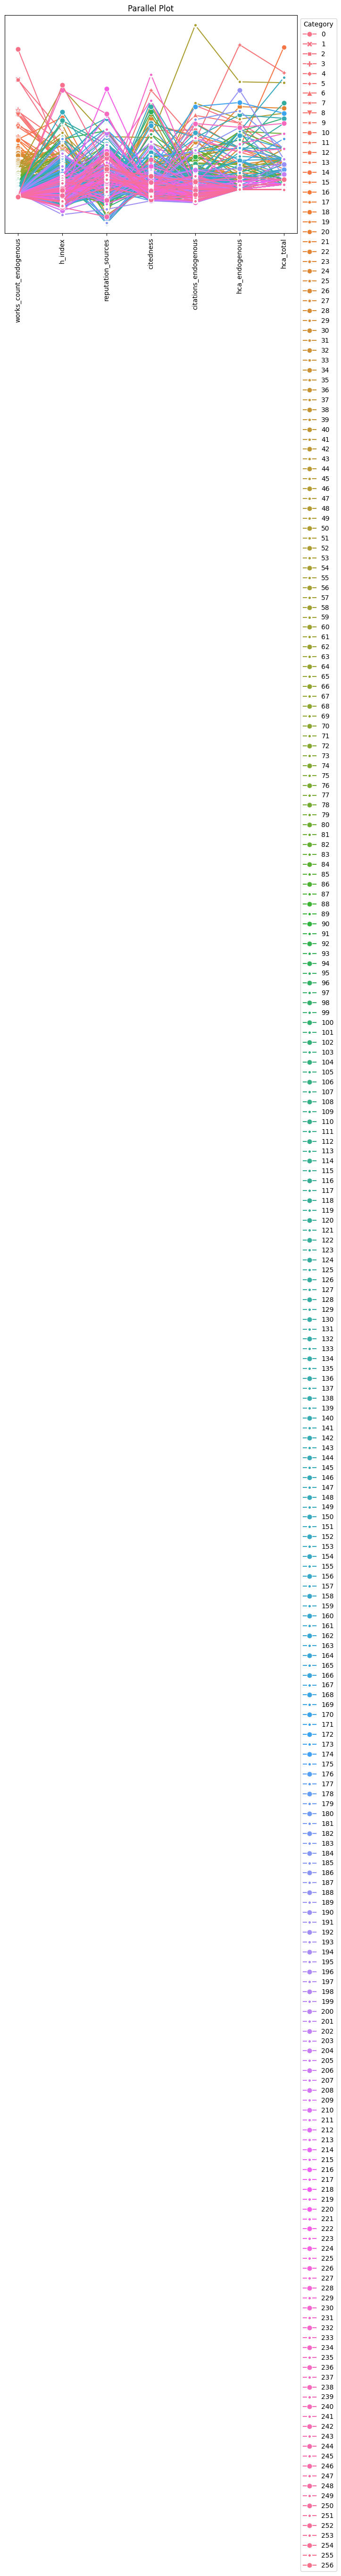

DONE!


In [145]:
if __name__ == "__main__":
    main()
    print("DONE!")